# Extracción de tuits: motivos para **NO** donar sangre (miedo, barreras)

Este cuaderno se centra solo en tuits sobre:
- Miedo a donar sangre
- Motivos para **no donar** / no poder donar
- Barreras, contraindicaciones, rechazo al donar

Flujo:
1. Búsqueda histórica (Full Archive 2022–actualidad) con query enfocada en **no donar / miedo**.
2. Selección de tuits con **más respuestas y likes** (conversaciones ricas).
3. Extracción de **respuestas** a esos tuits.
4. Guardado en CSV y tabla para lectura cualitativa.


In [1]:
import os
import time
import requests
import pandas as pd
from datetime import datetime, timezone, timedelta

BEARER_TOKEN = "AAAAAAAAAAAAAAAAAAAAAHiJ7AEAAAAALVTe7K2j%2BDiKwqC6xs0qPrBTcWA%3D49HVlM3W9jY9Ic9yBXC43BbYPsqZw9HS4eFbQyr46XCQPEA9x1"
headers = {"Authorization": f"Bearer {BEARER_TOKEN}"}
print("Bearer token cargado correctamente.")


Bearer token cargado correctamente.


In [2]:
SEARCH_URL = "https://api.twitter.com/2/tweets/search/all"

query = (
    "("
    "\"miedo a donar sangre\" OR \"miedo a donar\" OR \"miedo donar sangre\" "
    "OR \"miedo a las agujas\" OR \"fobia a las agujas\" "
    "OR \"no puedo donar sangre\" OR \"no puedo donar\" OR \"no me dejan donar\" "
    "OR \"no debo donar sangre\" OR \"no debo donar\" "
    "OR \"no quiero donar sangre\" OR \"no quiero donar\" "
    "OR \"rechazado para donar\" OR \"me rechazaron para donar\" "
    "OR \"contraindicación para donar\" OR \"contraindicado donar sangre\" "
    "OR \"mareo donando sangre\" OR \"desmayo donando sangre\" "
    ") lang:es -is:retweet"
)

params_base = {
    "query": query,
    "max_results": 100,
    "tweet.fields": "id,text,author_id,created_at,lang,public_metrics,geo,conversation_id,referenced_tweets",
    "user.fields": "id,name,username,location,public_metrics,created_at",
    "expansions": "author_id,geo.place_id",
    "place.fields": "id,full_name,country,country_code,place_type",
}

YEAR_RANGES = [
    ("2022-01-01T00:00:00Z", "2023-01-01T00:00:00Z"),
    ("2023-01-01T00:00:00Z", "2024-01-01T00:00:00Z"),
    ("2024-01-01T00:00:00Z", "2025-01-01T00:00:00Z"),
    ("2025-01-01T00:00:00Z", "2026-01-01T00:00:00Z"),
    ("2026-01-01T00:00:00Z", (datetime.now(timezone.utc) - timedelta(seconds=10)).strftime("%Y-%m-%dT%H:%M:%SZ")),
]

MAX_POR_ANO = 80

print("Búsqueda histórica 2022–actualidad por tramos anuales (motivos NO donar / miedo).")

def _tweet_to_row(t, users_by_id, places_by_id):
    user = users_by_id.get(t.get("author_id"), {})
    place_id = (t.get("geo") or {}).get("place_id")
    place = places_by_id.get(place_id, {}) if place_id else {}
    return {
        "tweet_id": t.get("id"),
        "created_at": t.get("created_at"),
        "text": t.get("text"),
        "lang": t.get("lang"),
        "retweet_count": (t.get("public_metrics") or {}).get("retweet_count"),
        "reply_count": (t.get("public_metrics") or {}).get("reply_count"),
        "like_count": (t.get("public_metrics") or {}).get("like_count"),
        "quote_count": (t.get("public_metrics") or {}).get("quote_count"),
        "author_id": t.get("author_id"),
        "author_username": user.get("username"),
        "author_name": user.get("name"),
        "author_location": user.get("location"),
        "place_full_name": place.get("full_name"),
        "place_country": place.get("country"),
        "place_country_code": place.get("country_code"),
        "place_type": place.get("place_type"),
        "reply_to_tweet_id": None,
    }

def search_tweets_por_ano_motivos(pause_seconds: float = 2.0):
    all_tweets = []
    for (start_time, end_time) in YEAR_RANGES:
        print(f"Buscando entre {start_time[:10]} y {end_time[:10]}...")
        params = params_base.copy()
        params["start_time"] = start_time
        params["end_time"] = end_time
        params["max_results"] = min(100, MAX_POR_ANO)

        resp = requests.get(SEARCH_URL, headers=headers, params=params)
        if resp.status_code != 200:
            print(f"  Error {resp.status_code}: {resp.text[:200]}...")
            continue

        data = resp.json()
        tweets = data.get("data", [])
        includes = data.get("includes", {})
        users_by_id = {u["id"]: u for u in includes.get("users", [])}
        places_by_id = {p["id"]: p for p in includes.get("places", [])}

        usados = 0
        for t in tweets[:MAX_POR_ANO]:
            all_tweets.append(_tweet_to_row(t, users_by_id, places_by_id))
            usados += 1
        print(f"  Año: {len(tweets)} tuits encontrados, usados {usados}. Total acumulado: {len(all_tweets)}")
        time.sleep(pause_seconds)

    return pd.DataFrame(all_tweets)

df_tweets = search_tweets_por_ano_motivos(pause_seconds=2.0)
print(f"Tuits obtenidos (motivos NO donar / miedo, 2022–actualidad): {len(df_tweets)}")

output_path = "twitter_motivos_no_donar_2022-2026.csv"
df_tweets.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"Guardado CSV en {output_path}")
display(df_tweets.head())


Búsqueda histórica 2022–actualidad por tramos anuales (motivos NO donar / miedo).
Buscando entre 2022-01-01 y 2023-01-01...
  Año: 77 tuits encontrados, usados 77. Total acumulado: 77
Buscando entre 2023-01-01 y 2024-01-01...
  Año: 76 tuits encontrados, usados 76. Total acumulado: 153
Buscando entre 2024-01-01 y 2025-01-01...
  Año: 76 tuits encontrados, usados 76. Total acumulado: 229
Buscando entre 2025-01-01 y 2026-01-01...
  Año: 79 tuits encontrados, usados 79. Total acumulado: 308
Buscando entre 2026-01-01 y 2026-03-05...
  Año: 76 tuits encontrados, usados 76. Total acumulado: 384
Tuits obtenidos (motivos NO donar / miedo, 2022–actualidad): 384
Guardado CSV en twitter_motivos_no_donar_2022-2026.csv


,tweet_id,created_at,text,lang,retweet_count,reply_count,like_count,quote_count,author_id,author_username,author_name,author_location,place_full_name,place_country,place_country_code,place_type,reply_to_tweet_id
0,1609261493173850114,2022-12-31T18:53:33.000Z,@TheKyojuro Y no puedo donar porque recien me ...,es,0,0,0,0,1378444797871058946,RenyX04,Reny04 - Editor de Videos,None,None,None,None,None,None
1,1609235641253912577,2022-12-31T17:10:49.000Z,Recién nms llegue a la ciudad de mi abuela y y...,es,2,1,12,0,985356133526392832,urfavleli,tu fav,"Central, Paraguay",None,None,None,None,None
2,1609204255155429376,2022-12-31T15:06:06.000Z,cualquiera diria q tengo fobia a las agujas,es,0,0,2,0,373285275,paaaaatttt_,Paaattt🫀,None,None,None,None,None,None
3,1609196339937566721,2022-12-31T14:34:39.000Z,"@Dane_larosa Yo también😌, aunque lo mío es por...",es,0,0,0,0,1568804244970512384,elmaiki1499,Maiki,None,None,None,None,None,None
4,1609192577659535363,2022-12-31T14:19:42.000Z,"Tengo muchas ganas de hacerme un tatuaje, pero...",es,0,0,0,0,3120130756,Roh_Rivero,𝙰𝚖𝚊𝚗𝚗𝚗,Río negro - Argentina,None,None,None,None,None


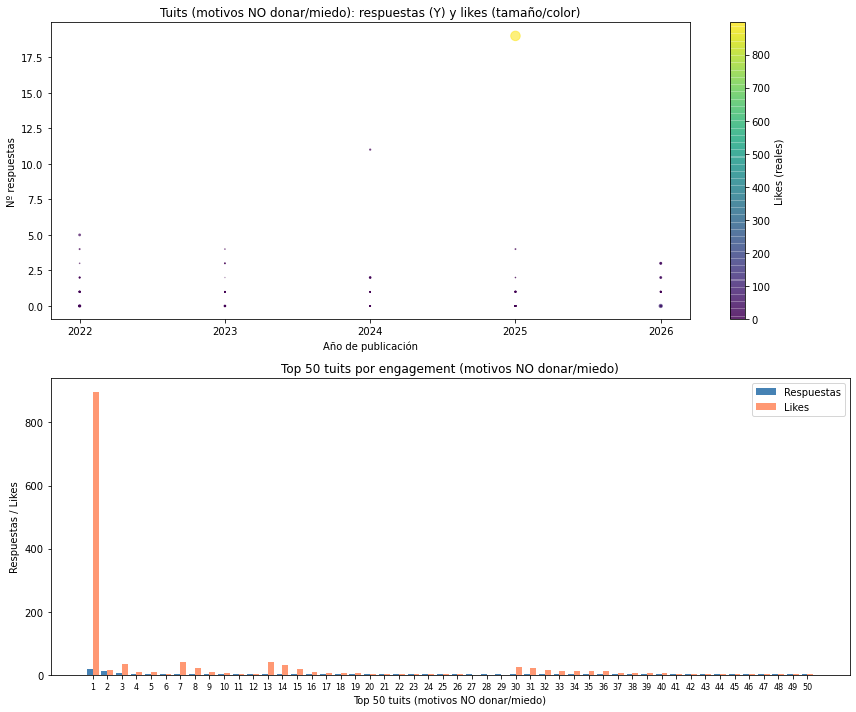

In [3]:
import matplotlib.pyplot as plt

if len(df_tweets) > 0:
    df = df_tweets.copy()
    df["reply_count"] = pd.to_numeric(df["reply_count"], errors="coerce").fillna(0).astype(int)
    df["like_count"]  = pd.to_numeric(df["like_count"], errors="coerce").fillna(0).astype(int)
    df["created_at_dt"] = pd.to_datetime(df["created_at"], errors="coerce")
    df["year"] = df["created_at_dt"].dt.year

    size_factor = 0.1

    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    ax1 = axes[0]
    df_plot = df.dropna(subset=["year"])
    sizes = (df_plot["like_count"] + 1) * size_factor
    scatter = ax1.scatter(
        df_plot["year"],
        df_plot["reply_count"],
        s=sizes,
        alpha=0.6,
        c=df_plot["like_count"],
        cmap="viridis",
    )
    ax1.set_xticks(sorted(df_plot["year"].unique()))
    ax1.set_xlabel("Año de publicación")
    ax1.set_ylabel("Nº respuestas")
    ax1.set_title("Tuits (motivos NO donar/miedo): respuestas (Y) y likes (tamaño/color)")
    plt.colorbar(scatter, ax=ax1, label="Likes (reales)")

    ax2 = axes[1]
    df_eng = df.sort_values(by=["reply_count", "like_count"], ascending=[False, False]).reset_index(drop=True)
    top50 = df_eng.head(50)
    x = range(len(top50))
    ax2.bar([i - 0.2 for i in x], top50["reply_count"], width=0.4, label="Respuestas", color="steelblue")
    ax2.bar([i + 0.2 for i in x], top50["like_count"], width=0.4, label="Likes", color="coral", alpha=0.8)
    ax2.set_xticks(x)
    ax2.set_xticklabels([str(i+1) for i in x], fontsize=8)
    ax2.set_ylabel("Respuestas / Likes")
    ax2.set_xlabel("Top 50 tuits (motivos NO donar/miedo)")
    ax2.set_title("Top 50 tuits por engagement (motivos NO donar/miedo)")
    ax2.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

    df_tweets = df_eng.drop(columns=["created_at_dt", "year"], errors="ignore")


In [4]:
TOP_TWEETS_POR_ENGAGEMENT = 40

if len(df_tweets) > 0:
    df_top = df_tweets.head(TOP_TWEETS_POR_ENGAGEMENT).copy()
    print(f"Seleccionados {len(df_top)} tuits con más engagement (motivos NO donar/miedo).")
    print(f"Ejemplo: reply_count máx = {df_top['reply_count'].max()}, like_count máx = {df_top['like_count'].max()}.")
else:
    df_top = pd.DataFrame()


Seleccionados 40 tuits con más engagement (motivos NO donar/miedo).
Ejemplo: reply_count máx = 19, like_count máx = 897.


In [5]:
REPLIES_PER_TWEET = 20

def fetch_replies_for_tweets(df_root, max_replies_per_tweet=10, pause_seconds=1.5):
    if len(df_root) == 0:
        return df_root

    reply_params_base = {
        "max_results": min(100, max_replies_per_tweet),
        "tweet.fields": "id,text,author_id,created_at,lang,public_metrics,conversation_id,referenced_tweets",
        "user.fields": "id,name,username,location",
        "expansions": "author_id",
    }
    all_replies = []
    for i, row in df_root.iterrows():
        tid = row["tweet_id"]
        q = f"conversation_id:{tid} -is:retweet"
        resp = requests.get(SEARCH_URL, headers=headers, params={"query": q, **reply_params_base})
        if resp.status_code == 402:
            print("Error 402 al obtener respuestas. Se guardan solo los tuits raíz.")
            break
        if resp.status_code != 200:
            continue

        data = resp.json()
        tweets = data.get("data", [])
        includes = data.get("includes", {})
        users_by_id = {u["id"]: u for u in includes.get("users", [])}
        places_by_id = {}
        for t in tweets:
            r = _tweet_to_row(t, users_by_id, places_by_id)
            r["reply_to_tweet_id"] = tid
            all_replies.append(r)

        if (i + 1) % 10 == 0:
            print(f"  Respuestas obtenidas para {i+1}/{len(df_root)} tuits. Total respuestas: {len(all_replies)}")
        time.sleep(pause_seconds)

    if all_replies:
        df_root = df_root.copy()
        df_root["reply_to_tweet_id"] = None
        return pd.concat([df_root, pd.DataFrame(all_replies)], ignore_index=True)
    return df_root

if len(df_top) > 0:
    print("Obteniendo respuestas (conversación) para tuits de motivos NO donar/miedo...")
    df_conv = fetch_replies_for_tweets(df_top, max_replies_per_tweet=REPLIES_PER_TWEET, pause_seconds=1.5)
    print(f"Total (tuits raíz + respuestas): {len(df_conv)}")
else:
    df_conv = pd.DataFrame()


Obteniendo respuestas (conversación) para tuits de motivos NO donar/miedo...
  Respuestas obtenidas para 10/40 tuits. Total respuestas: 18
  Respuestas obtenidas para 20/40 tuits. Total respuestas: 28
  Respuestas obtenidas para 30/40 tuits. Total respuestas: 28
  Respuestas obtenidas para 40/40 tuits. Total respuestas: 31
Total (tuits raíz + respuestas): 71


In [6]:
if len(df_conv) > 0:
    output_conv = "twitter_motivos_no_donar_con_respuestas.csv"
    df_conv.to_csv(output_conv, index=False, encoding="utf-8-sig")
    print(f"Guardado CSV con tuits + respuestas en {output_conv}\n")
    print("Vista previa (primeras filas):")

    pd.set_option("display.max_colwidth", 200)
    columnas_lectura = ["text", "author_username", "created_at", "reply_count", "like_count", "reply_to_tweet_id"]
    columnas_lectura = [c for c in columnas_lectura if c in df_conv.columns]
    display(df_conv[columnas_lectura].head(50))
else:
    print("No hay datos de conversación para mostrar.")


Guardado CSV con tuits + respuestas en twitter_motivos_no_donar_con_respuestas.csv

Vista previa (primeras filas):


,text,author_username,created_at,reply_count,like_count,reply_to_tweet_id
0,cada vez que veo una persona anti vacunas pienso automaticamente que la razon por la que quieren prohibir las vacunas es porque le tienen miedo a las agujas https://t.co/JfWRpKDYuT,HORMIGA_RETURNS,2025-12-23T13:24:32.000Z,19,897,None
1,NO QUIERO DONAR ESQUIZOFRÉNICA PERO SKZ CREO QUE SKZ NO TIENE NINGUN TEMA QUE EMPIECE CON P Y ESO ME ESTA PONIENDO NERVIOSA,mindonsatur,2024-12-28T18:56:17.000Z,11,16,None
2,Ahorita una doña gritó al cajero NO NO QUIERO DONAR,soysnoopylover,2022-12-30T20:52:17.000Z,5,34,None
3,oye ahora q lo pienso no puedo donar sangre xq soy un drogadicto y tengo 54 enfermedades pero médula? podría donar médula un drogadicto con 54 enfermedades o tampoco?,mmmsobacos,2022-12-29T22:15:53.000Z,4,10,None
4,A mí esto me da mucha pena cómo me vas a decir que no puedo donar sangre porque peso poco cuando soy donante universal (0-) y siempre están buscando gente de ese grupo sanguíneo… https://t.co/qNcZ...,coeliachoe,2025-12-18T09:36:08.000Z,4,8,None
5,"@ana_grimbaum Es fácil tirar abajo ese relato.\n""No puedo donar de mi sueldo, tengo un estilo de vida que matener"" Luis Alberto Alejandro Aparicio Lacalle Pou. \nJosé Mujica dona 400.000 dólares d...",Graldelpueblo,2023-12-31T13:48:53.000Z,4,3,None
6,"SEGUNDO PINCHAZO DEL DÍA, MI MUESTRA SE COAGULÓ ASI QUE ME SACARON OTRA 😭😭(,LE TENGO FOBIA A LAS AGUJAS asi que me hiperventilé x2) https://t.co/aD39mWd6rC https://t.co/Zi0nyj9Zgu",CRUNCH_LINERS,2026-02-24T17:25:13.000Z,3,41,None
7,"Soy O- y simplemente no puedo donar sangre a nadie porque mi peso es de 40 kilos.\n\nConseguir donantes de sangre en un país donde la desnutrición está normalizada, eso es un reto. https://t.co/T3...",ArepitaLigera,2026-03-04T17:03:19.000Z,3,20,None
8,"SUELTENME, YA NO QUIERO DONAR SUBS Y ME OBLIGAN MINIMO 5 POR STREAM😭😭 https://t.co/x7xkxGrYVW",bea28louis,2026-03-04T01:24:32.000Z,3,9,None
9,"IVI Dono ayer me dio la triste noticia de que, pese a tener rasgos caucásicos™, no puedo donar semen porque mi padre es ecuatoriano y, ya sabéis, mezcla de razas. Se cierra un arco que nunca despe...",vizepto,2023-12-30T10:30:53.000Z,3,7,None
